In [6]:
# Install torchsummary
!pip install torchsummary --quiet

In [7]:
import torch

In [8]:
!pip install comet_ml > /dev/null 2>&1
import comet_ml
# TODO: ENTER YOUR API KEY HERE!!
COMET_API_KEY = ""

# Check that we are using a GPU, if not switch runtimes
#   using Runtime > Change Runtime Type > GPU
assert torch.cuda.is_available(), "Please enable GPU from runtime settings"
assert COMET_API_KEY != "", "Please insert your Comet API Key"

# Set GPU for computation
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device ="cuda"

In [10]:
# === Standard library ===
import os
import shutil
import random
from pathlib import Path

# === Numerics / plotting ===
import numpy as np
import matplotlib.pyplot as plt

# === Progress / utils ===
from tqdm.auto import tqdm

# === Imaging ===
from PIL import Image

# === PyTorch core ===
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# === PyTorch data ===
from torch.utils.data import DataLoader
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# === TorchVision models ===
from torchvision import models

# === Summaries / logging ===
from torchsummary import summary
import comet_ml

# === External helpers ===
import mitdeeplearning as mdl
import kagglehub


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
# Model Visualization
!pip install torchinfo
!pip install torchviz

from torchinfo import summary
import torch
from torchviz import make_dot
from IPython.display import display, Image

Download datasets from kaggle [link](https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2)



In [12]:
# Download latest version
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

print("Path to dataset files:", path)

100%|██████████| 744M/744M [00:03<00:00, 228MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/8


In [14]:
#dataset_path = "/kaggle/input/garbage-classification-v2/garbage-dataset"

dataset_path = path + "/garbage-dataset"
print("Files in dataset:")
classes = os.listdir(dataset_path)
print(classes)

Files in dataset:
['metal', 'trash', 'cardboard', 'plastic', 'clothes', 'battery', 'paper', 'biological', 'shoes', 'glass']


In [15]:
index_to_label = ["battery", "biological", "cardboard", "clothes", "glass", "metal", "paper", "plastic", "shoes", "trash"]

Visualize what some of these images and their corresponding training **labels**

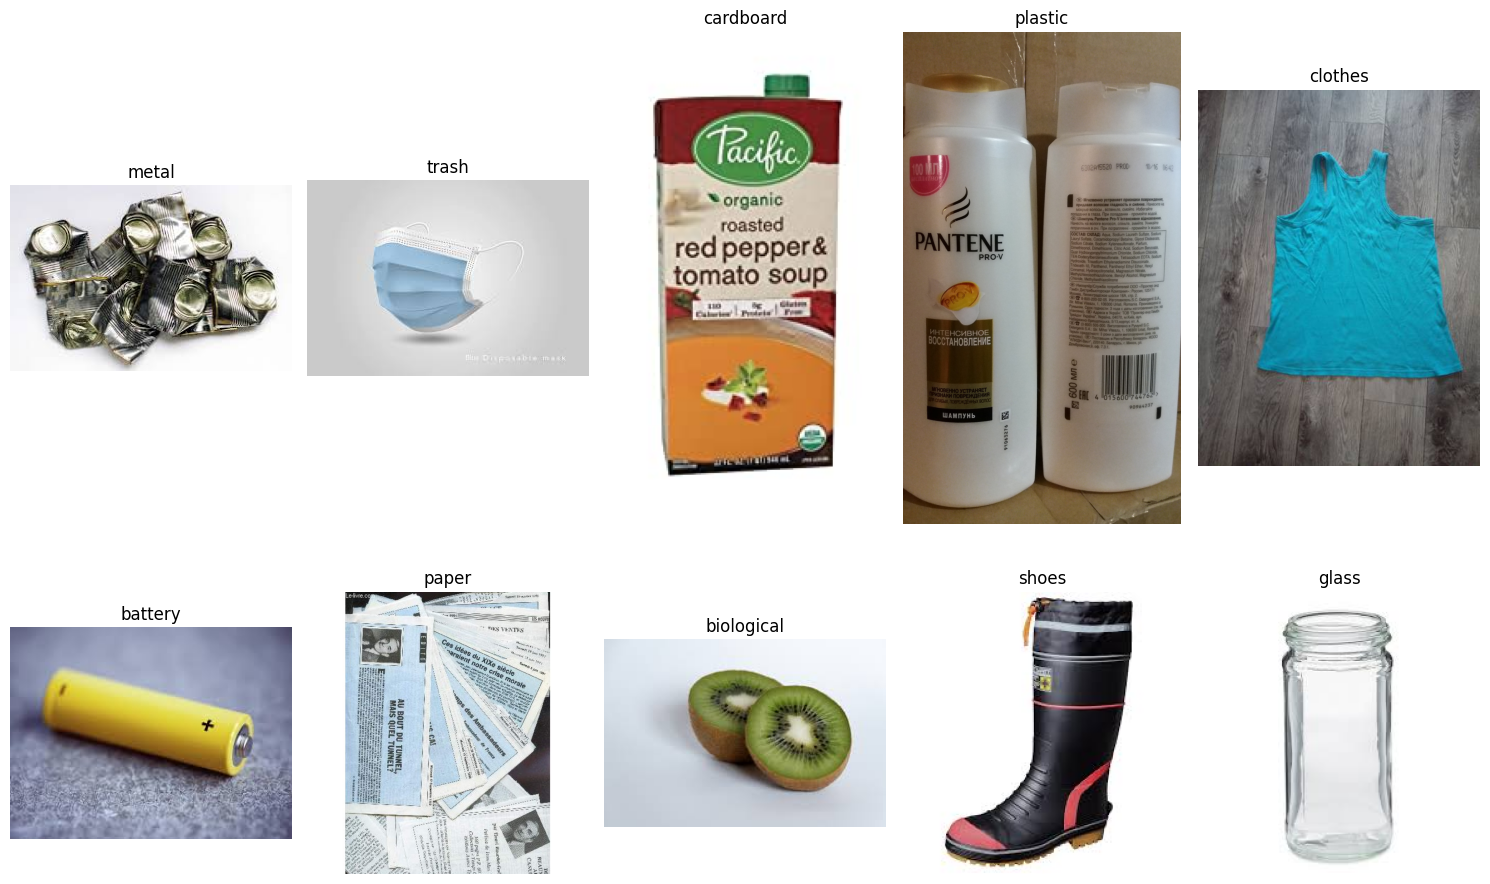

In [17]:
from PIL import Image
# Plot one sample image from each class
plt.figure(figsize=(15, 10))

for i, cls in enumerate(classes):
    class_dir = os.path.join(dataset_path, cls)
    # Find the first jpg file in the folder
    img_name = next((f for f in os.listdir(class_dir) if f.lower().endswith('.jpg')), None)
    if img_name:
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.tight_layout()
plt.show()

Split Data to kaggle/working

In [18]:
# Destination directories
data_root = "/kaggle/working/data"
train_dir = os.path.join(data_root, "train")
val_dir   = os.path.join(data_root, "val")
test_dir  = os.path.join(data_root, "test")

# Create new folders
for dir_path in [train_dir, val_dir, test_dir]:
    os.makedirs(dir_path, exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Loop through each class folder
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_path):
        continue  # skip non-folder items

    # Make subfolders for each split
    for split_dir in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(split_dir, class_name), exist_ok=True)

    # List all images
    images = os.listdir(class_path)
    random.shuffle(images)

    # Compute split indices
    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_files = images[:train_end]
    val_files = images[train_end:val_end]
    test_files = images[val_end:]

    # Copy images
    def copy_files(file_list, dest_folder):
        for fname in file_list:
            src = os.path.join(class_path, fname)
            dst = os.path.join(dest_folder, class_name, fname)
            shutil.copy2(src, dst)

    copy_files(train_files, train_dir)
    copy_files(val_files, val_dir)
    copy_files(test_files, test_dir)

print("Dataset split completed!")


Dataset split completed!


In [19]:
for split in ['train', 'val', 'test']:
    path = f'/kaggle/working/data/{split}/.ipynb_checkpoints'
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Removed {path}")

print("Cleanup complete — you can now reload your datasets.")

Cleanup complete — you can now reload your datasets.


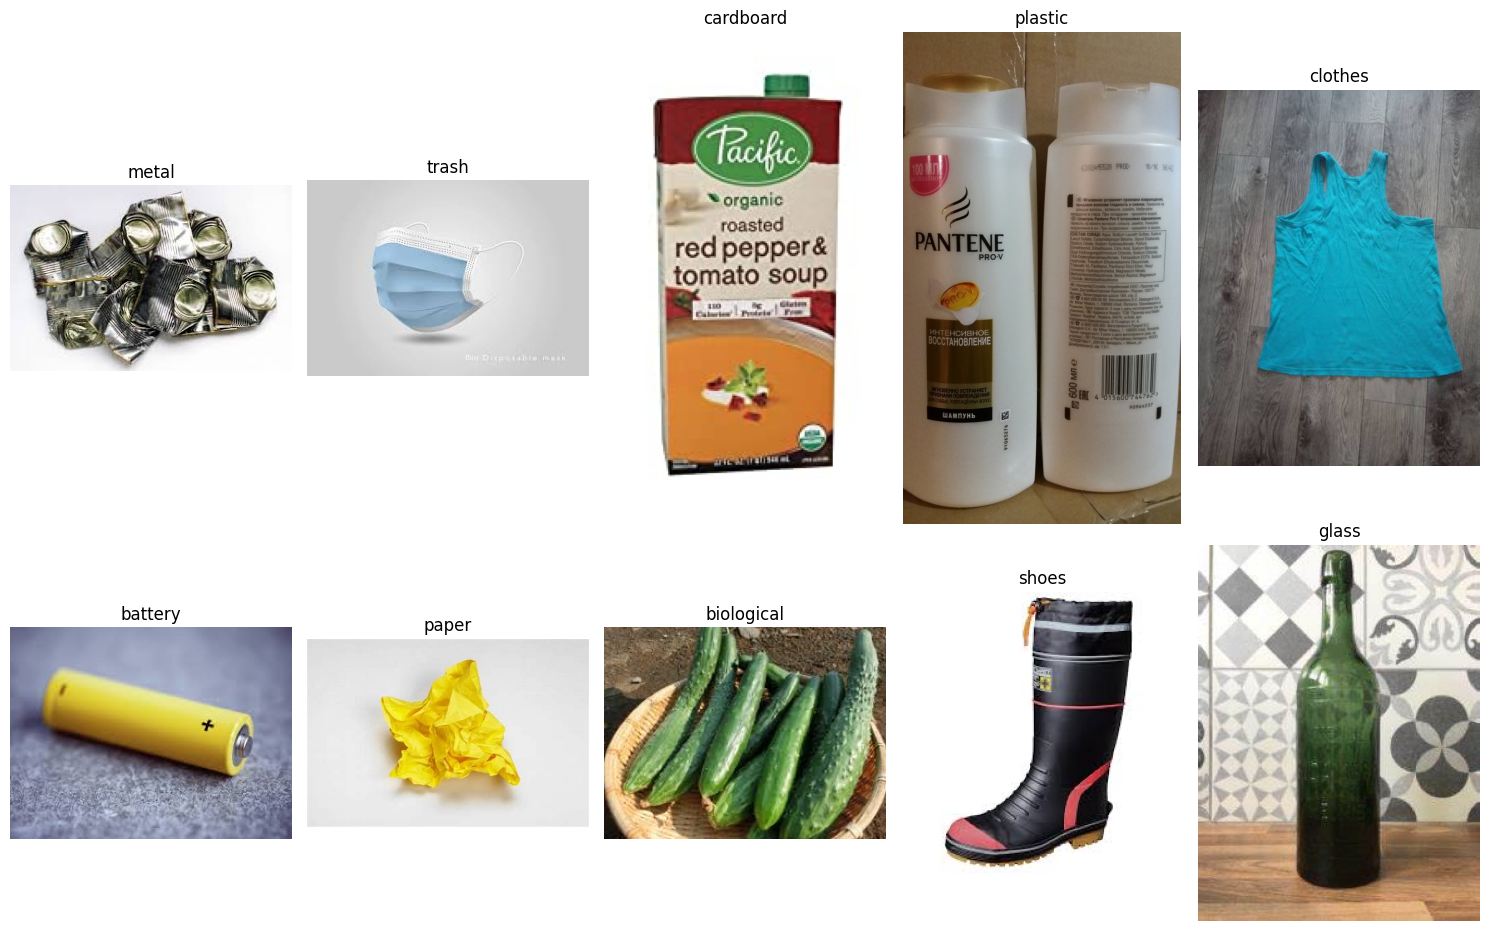

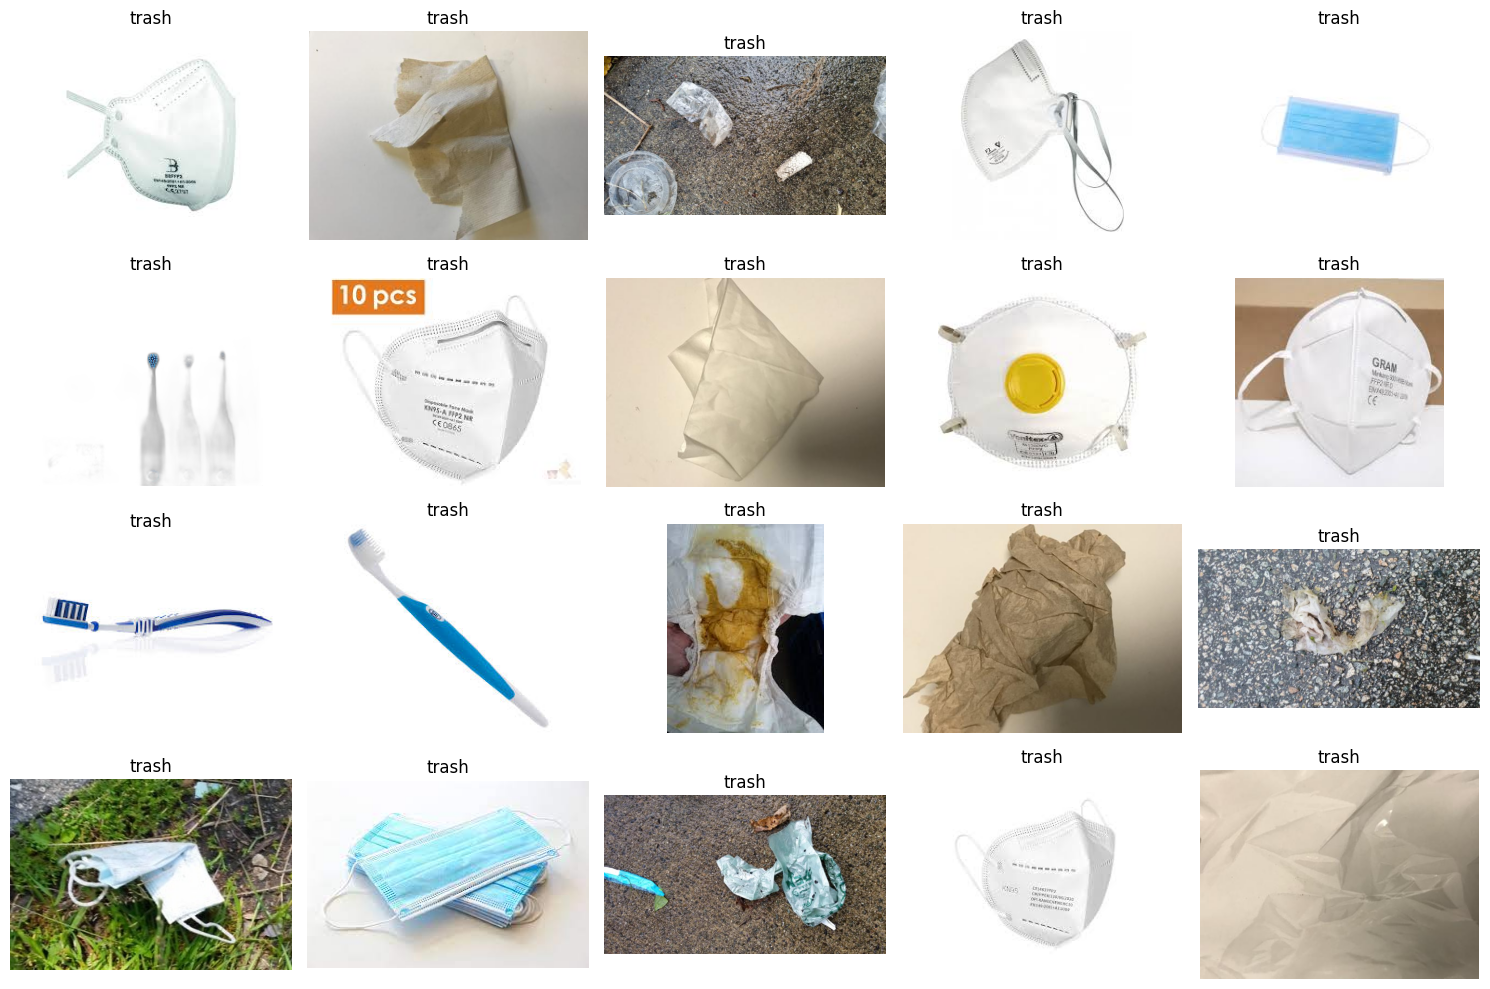

In [20]:
train_classes = os.listdir(train_dir)

plt.figure(figsize=(15, 10))

for i, cls in enumerate(train_classes):
    class_dir = os.path.join(train_dir, cls)
    # Find the first jpg file in the folder
    img_name = next((f for f in os.listdir(class_dir) if f.lower().endswith('.jpg')), None)
    if img_name:
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.tight_layout()
plt.show()
# Choose one class
target_class = "trash"   # 🔹 change this to any class name you want
class_dir = os.path.join(train_dir, target_class)

# List all images in that class
all_images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# Randomly select up to 10 images
sample_images = random.sample(all_images, min(20, len(all_images)))

# Plot them
plt.figure(figsize=(15, 10))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(class_dir, img_name)
    img = Image.open(img_path)
    plt.subplot(4, 5, i + 1)   # 2 rows × 5 columns = 10 images
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")

plt.tight_layout()
plt.show()

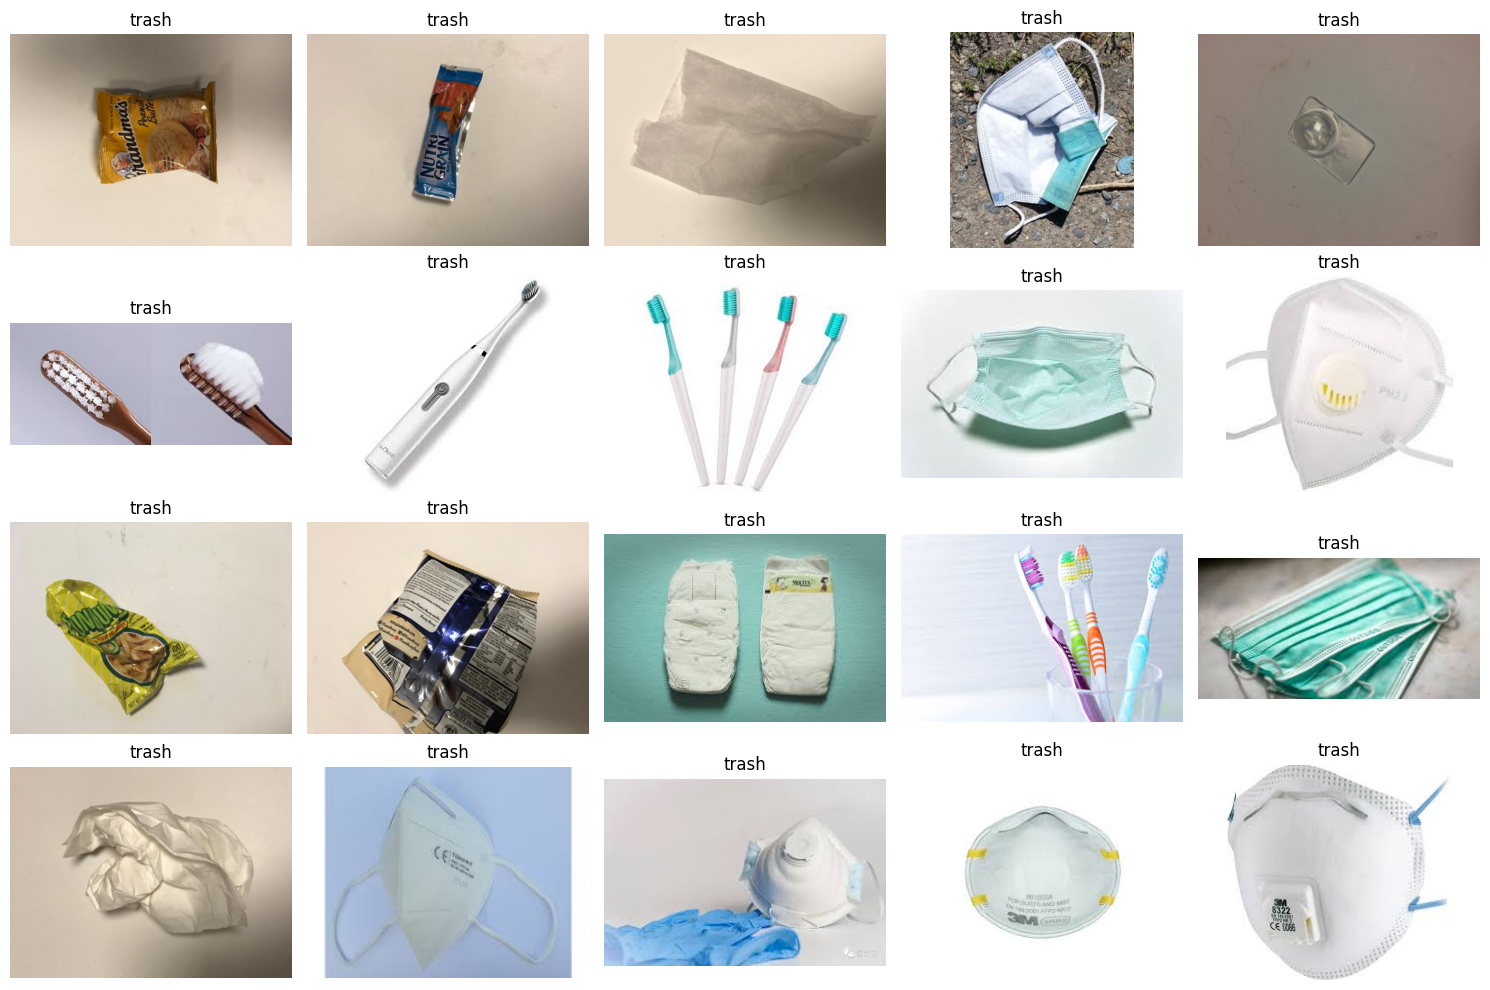

In [21]:
# Choose one class
target_class = "trash"   # 🔹 change this to any class name you want
class_dir = os.path.join(train_dir, target_class)

# List all images in that class
all_images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# Randomly select up to 10 images
sample_images = random.sample(all_images, min(20, len(all_images)))

# Plot them
plt.figure(figsize=(15, 10))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(class_dir, img_name)
    img = Image.open(img_path)
    plt.subplot(4, 5, i + 1)   # 2 rows × 5 columns = 10 images
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# colored
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # Resize all images to 128x128
    transforms.ToTensor(),           # Convert to tensor and scale [0, 255] → [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize around 0
])

'''
# gray scale
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])
'''

'\n# gray scale\ntransform = transforms.Compose([\n    transforms.Resize((128, 128)),\n    transforms.Grayscale(num_output_channels=1),\n    transforms.ToTensor()\n])\n'

In [23]:
# Load datasets
data_root = "/kaggle/working/data"
train_dir = os.path.join(data_root, "train")
val_dir   = os.path.join(data_root, "val")
test_dir  = os.path.join(data_root, "test")

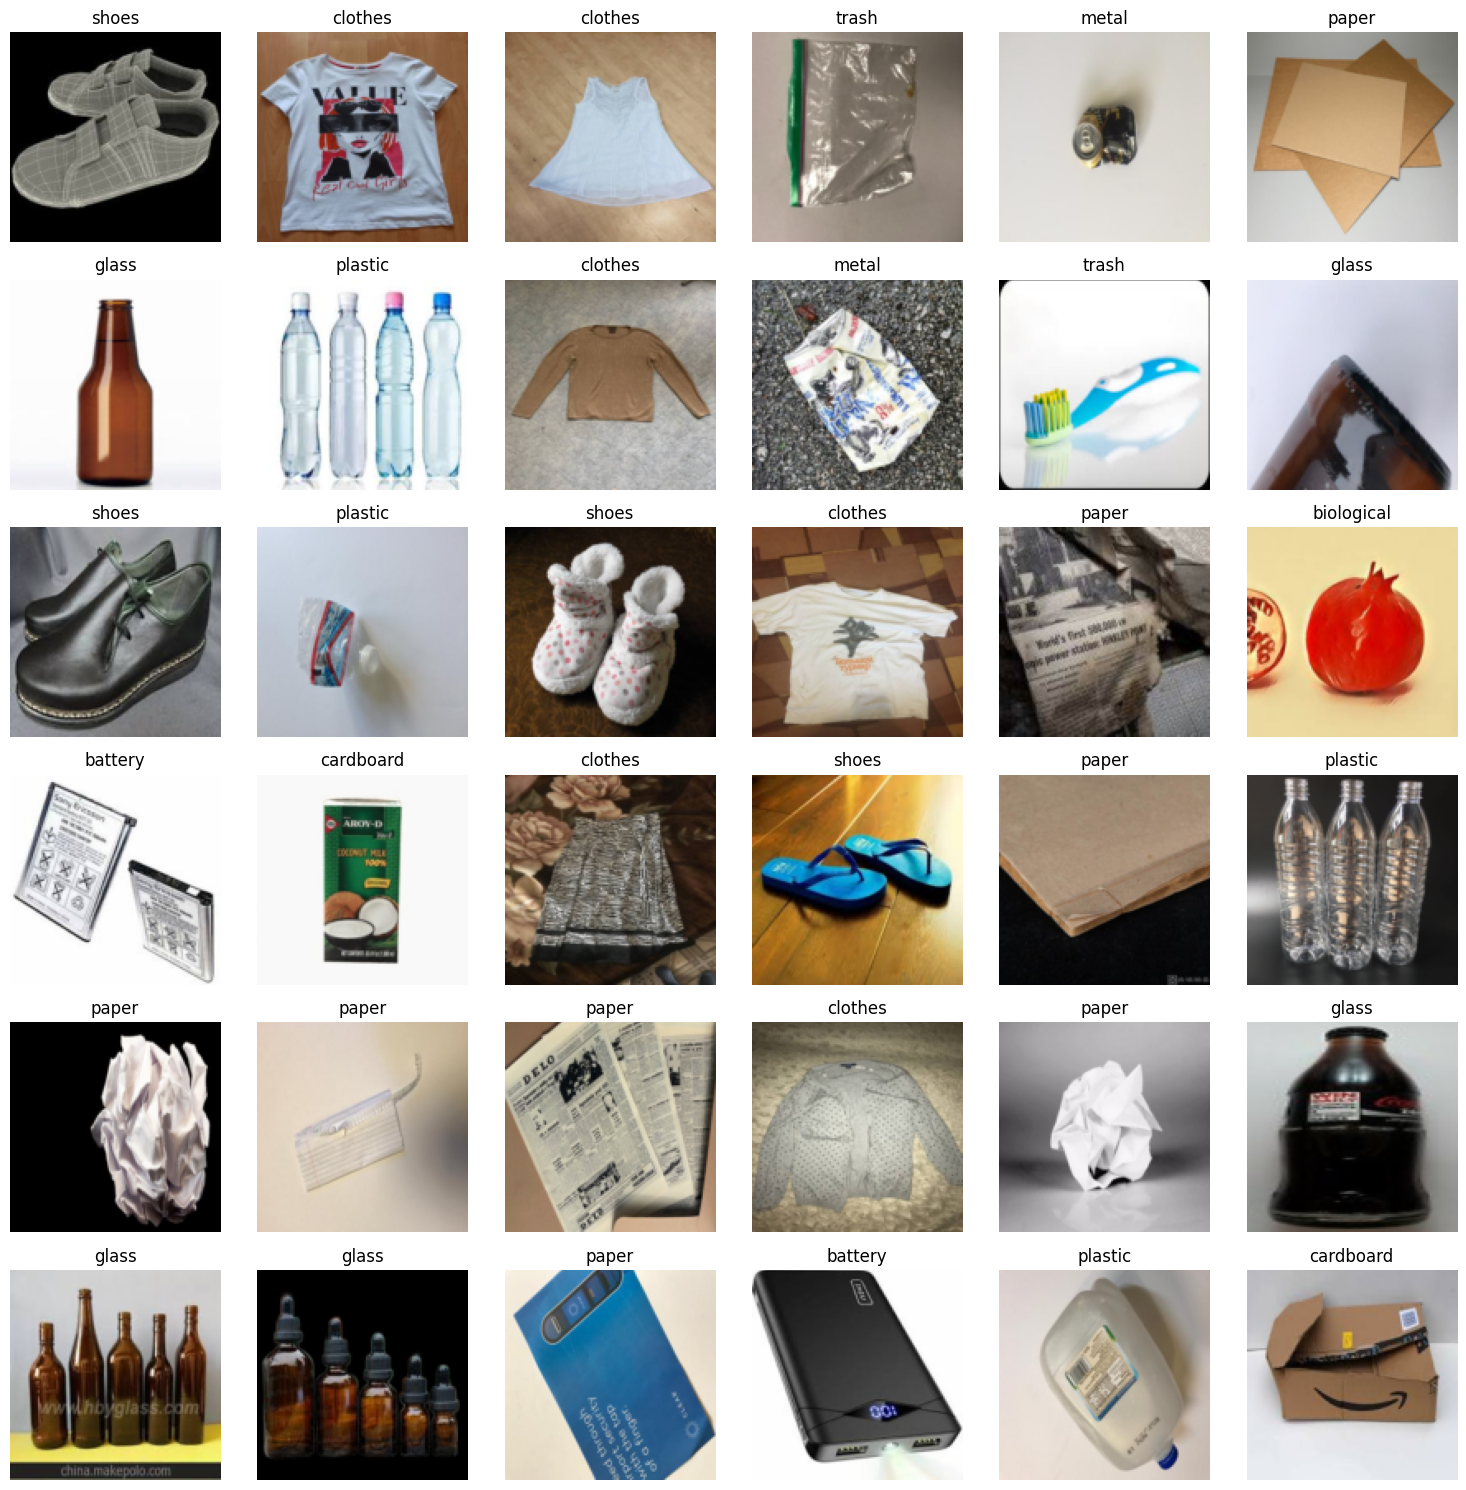

In [24]:
from torchvision import datasets as tv_datasets, transforms
train_dataset = tv_datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset   = tv_datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset  = tv_datasets.ImageFolder(root=test_dir, transform=transform)
plt.figure(figsize=(15, 15))
random_inds = np.random.choice(len(train_dataset), 36, replace=False)

for i, image_ind in enumerate(random_inds):
    image, label = train_dataset[image_ind]

    # Convert from (C, H, W) → (H, W, C)
    img_np = image.permute(1, 2, 0).numpy()

    # Optional: unnormalize if you used transforms.Normalize earlier
    img_np = (img_np * 0.5) + 0.5  # because you used Normalize((0.5,...), (0.5,...))

    plt.subplot(6, 6, i + 1)
    plt.imshow(img_np)
    plt.title(train_dataset.classes[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

#1) non-pretrained CNN Model

Start Comet Project

In [25]:
# start a first comet experiment for the first part of the lab
comet_ml.init(project_name="WasteClassificationCNN")
comet_model_1 = comet_ml.Experiment()

COMET WARNING: comet_ml.init() is deprecated and will be removed soon. Please use comet_ml.login()


Please paste your Comet API key from https://www.comet.com/api/my/settings/
(api key may not show as you type)
Comet API key: ··········


COMET INFO: Valid Comet API Key saved in /root/.comet.config (set COMET_CONFIG to change where it is saved).
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/parkorn-tuntiwattanakhul/wasteclassificationcnn/eb500c209c25420388314e72d4a059d6



#Create Training set and Testing set

In [26]:
# Create DataLoaders for batch processing
BATCH_SIZE = 64
trainset_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
testset_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --------------------------------------------------------------------------
# Define Non Pre-Trained CNN Model (Randomly Initialized CNN model)
# --------------------------------------------------------------------------

In [27]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, input_size=128,
                 C1=24, C2=21, H=591):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, C1, kernel_size=3, bias=True)  # 128->126
        self.pool1 = nn.MaxPool2d(2,2)                                     # 126->63
        self.conv2 = nn.Conv2d(C1, C2, kernel_size=3, bias=True)           # 63->61
        self.pool2 = nn.MaxPool2d(2,2)                                     # 61->30

        self.relu = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()

        flattened = 30*30*C2                                              # 900*C2
        self.fc1 = nn.Linear(flattened, H, bias=True)
        self.dropout = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(H, num_classes, bias=True)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Instantiate the model
cnn_model = CNN().to(device)
print(cnn_model)

CNN(
  (conv1): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(24, 21, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU(inplace=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=18900, out_features=591, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=591, out_features=10, bias=True)
)


In [28]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

cnn_total, cnn_trainable = count_parameters(cnn_model)

print("===== PARAMETERS =====")
print(f"CNN:")
print(f"  Total parameters     : {cnn_total:,}")
print(f"  Trainable parameters : {cnn_trainable:,}")

===== PARAMETERS =====
CNN:
  Total parameters     : 11,181,640
  Trainable parameters : 11,181,640


#Define Evaluation function

In [29]:
def evaluate(model, dataloader, loss_function):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            test_loss += loss.item() * images.size(0)

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return test_loss / total, correct / total

In [30]:
for images, labels in trainset_loader:
    print(images.shape)
    break

torch.Size([64, 3, 128, 128])


#Define Training Parameters

In [31]:
# Rebuild the CNN model
cnn_model = CNN().to(device)

# Define hyperparams
batch_size = 64
epochs = 7
learning_rate = 0.001
weight_decay  = 5e-4

optimizer = optim.AdamW(cnn_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss_function = nn.CrossEntropyLoss()

# Redefine trainloader with new batch size parameter
trainset_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testset_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [32]:
print(train_dataset[0][0].shape) #check dataset's size to match the parameters

torch.Size([3, 128, 128])


Training Step

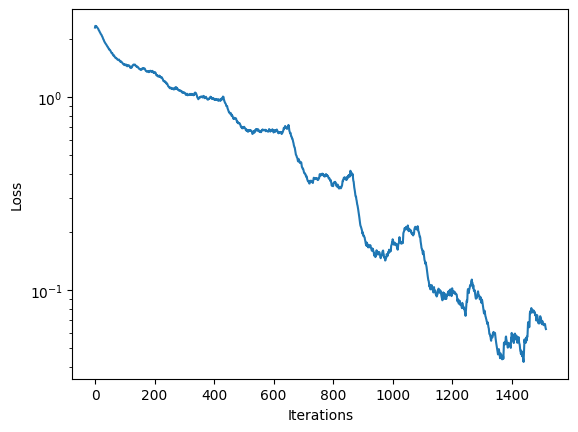

Epoch 7: train_loss=0.0588 acc=0.9825 | val_loss=1.6846 acc=0.6923


{'web': 'https://www.comet.com/api/image/download?imageId=ca32381436fa433f931e74d4cb176217&experimentKey=e6b9293d1bbe4614a066834cf0805f90',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=ca32381436fa433f931e74d4cb176217&experimentKey=e6b9293d1bbe4614a066834cf0805f90',
 'imageId': 'ca32381436fa433f931e74d4cb176217'}

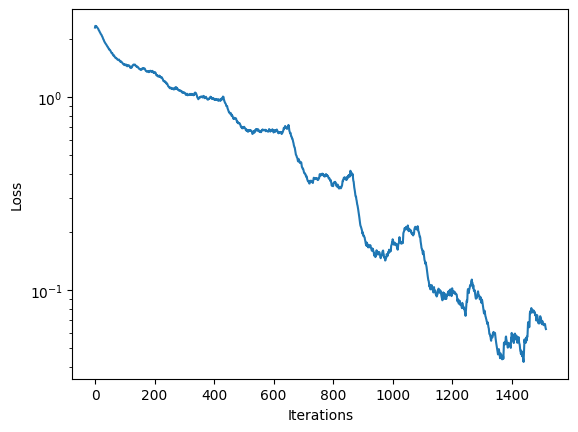

In [33]:
loss_history = mdl.util.LossHistory(smoothing_factor=0.95) # to record the evolution of the loss
plotter = mdl.util.PeriodicPlotter(sec=2, xlabel='Iterations', ylabel='Loss', scale='semilogy')

# Initialize new comet experiment
comet_ml.init(project_name="Deep_Learning_Project_1")
comet_model = comet_ml.Experiment()

if hasattr(tqdm, '_instances'): tqdm._instances.clear() # clear if it exists

# Training loop!
cnn_model.train()

for epoch in range(epochs):
    total_loss = 0
    running_loss = 0.0
    correct_pred = 0
    total_pred = 0

    # First grab a batch of training data which our data loader returns as a tensor
    for idx, (images, labels) in enumerate(tqdm(trainset_loader)):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        logits = cnn_model(images)

        loss = loss_function(logits, labels)

        # Get the loss and log it to comet and the loss_history record
        loss_value = loss.item()
        comet_model.log_metric("loss", loss_value, step=idx)
        loss_history.append(loss_value) # append the loss to the loss_history record
        plotter.plot(loss_history.get())

        # Backpropagation/backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss_value * images.size(0)

        # Get the prediction and tally metrics
        predicted = torch.argmax(logits, dim=1)
        correct_pred += (predicted == labels).sum().item()
        total_pred += labels.size(0)

    # Compute metrics
    train_loss = running_loss / total_pred
    train_acc  = correct_pred / total_pred
    val_loss, val_acc = evaluate(cnn_model, testset_loader, loss_function)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")
comet_model.log_figure(figure=plt)

#Save the CNN model to Comet

In [34]:
torch.save(cnn_model.state_dict(), "cnn_model.pt")

#Evaluate CNN Model

In [35]:
val_loss, val_acc = evaluate(cnn_model, testset_loader, loss_function)
print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

Validation Loss: 1.6846, Accuracy: 0.6923


In [36]:
random_inds = np.random.choice(len(train_dataset), 36, replace=False)
test_image, test_label = test_dataset[0]
test_image = test_image.to(device).unsqueeze(0)

# put the model in evaluation (inference) mode
cnn_model.eval()
predictions_test_image = cnn_model(test_image)

In [37]:
random_inds = np.random.choice(len(test_dataset), 50, replace=False)  # 5 random samples

for idx in random_inds:
    test_image, test_label = test_dataset[idx]
    test_image = test_image.to(device).unsqueeze(0)

    cnn_model.eval()
    with torch.no_grad():
        predictions = cnn_model(test_image)
        predicted_label = torch.argmax(predictions, dim=1).item()

    print(f"True: {test_dataset.classes[test_label]:<12}, Predicted: {test_dataset.classes[predicted_label]:<12}", end=" ")
    if (test_label != predicted_label):
        print("wrong")
    else:
        print("correct")

True: clothes     , Predicted: clothes      correct
True: paper       , Predicted: paper        correct
True: paper       , Predicted: glass        wrong
True: plastic     , Predicted: plastic      correct
True: cardboard   , Predicted: paper        wrong
True: glass       , Predicted: plastic      wrong
True: battery     , Predicted: battery      correct
True: glass       , Predicted: plastic      wrong
True: clothes     , Predicted: clothes      correct
True: biological  , Predicted: glass        wrong
True: biological  , Predicted: biological   correct
True: clothes     , Predicted: clothes      correct
True: shoes       , Predicted: paper        wrong
True: battery     , Predicted: cardboard    wrong
True: plastic     , Predicted: plastic      correct
True: clothes     , Predicted: clothes      correct
True: shoes       , Predicted: shoes        correct
True: clothes     , Predicted: clothes      correct
True: paper       , Predicted: paper        correct
True: clothes     , Predic

In [38]:
print(predictions_test_image)

tensor([[  8.0729,  -9.1681,   4.6701, -17.6301,   3.2468,  -7.2581,  -3.5418,
          -2.7086,  -1.4781,  -5.0730]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


Random test sample index: 2401
True label: plastic
Predicted: plastic  (p=0.9488)
Top-5:
  1. plastic: 0.9488
  2. cardboard: 0.0309
  3. glass: 0.0195
  4. metal: 0.0008
  5. trash: 0.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


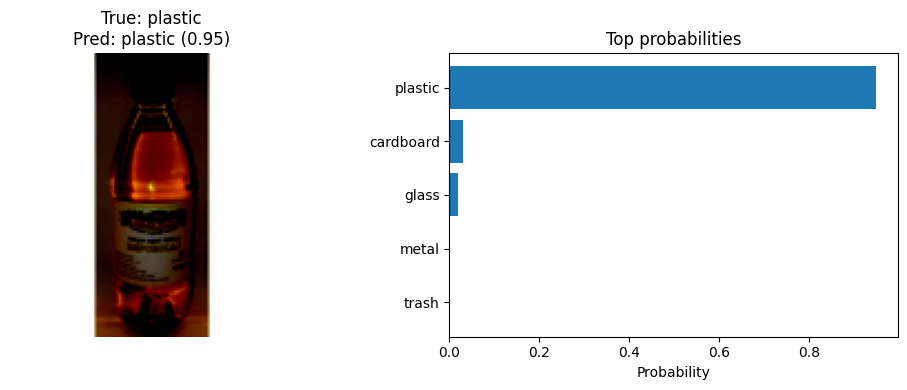

In [39]:
DEVICE = device  # use your existing 'device'
MODEL  = cnn_model
DATASET = test_dataset            # torch.utils.data.Dataset
IDX2LBL = index_to_label          # e.g., {0:"cat",1:"dog",...}

# Set to True if you used transforms.Normalize on the dataset
DENORMALIZE = False
# Fill these if DENORMALIZE=True (use your actual dataset mean/std)
MEAN = [0.485, 0.456, 0.406]  # example (ImageNet-style)
STD  = [0.229, 0.224, 0.225]

def denorm(img_tensor, mean, std):
    """
    img_tensor: (C,H,W) in torch.FloatTensor
    returns: (C,H,W) de-normalized, clipped to [0,1]
    """
    m = torch.tensor(mean, device=img_tensor.device).view(-1, 1, 1)
    s = torch.tensor(std,  device=img_tensor.device).view(-1, 1, 1)
    out = img_tensor * s + m
    return out.clamp(0, 1)

# ---- sample 1 image from test set ----
MODEL.eval()
idx = random.randrange(len(DATASET))
img, true_label = DATASET[idx]   # img: (3,H,W), true_label: int

# (optional) de-normalize for display only
disp_img = denorm(img, MEAN, STD) if DENORMALIZE else img

# move to device, add batch dim
img_batch = img.unsqueeze(0).to(DEVICE)

# ---- forward pass ----
with torch.no_grad():
    logits = MODEL(img_batch)           # (1, num_classes)
    probs  = F.softmax(logits, dim=1)   # (1, num_classes)

probs_np = probs.squeeze(0).cpu().numpy()     # (num_classes,)
pred_idx = int(probs.argmax(dim=1).item())
pred_lbl = IDX2LBL[pred_idx]
true_lbl_name = IDX2LBL[int(true_label)]

# ---- sort classes by probability (descending) ----
classes = [IDX2LBL[i] for i in range(len(probs_np))]
order = np.argsort(-probs_np)
sorted_probs = probs_np[order]
sorted_classes = [classes[i] for i in order]

# ---- print top-5 ----
topk = 5 if len(sorted_probs) >= 5 else len(sorted_probs)
print(f"Random test sample index: {idx}")
print(f"True label: {true_lbl_name}")
print(f"Predicted: {pred_lbl}  (p={probs_np[pred_idx]:.4f})")
print("Top-5:")
for k in range(topk):
    print(f"  {k+1}. {sorted_classes[k]}: {sorted_probs[k]:.4f}")

# ---- plot image + probability bar chart ----
plt.figure(figsize=(10,4))

# left: image
plt.subplot(1,2,1)
plt.imshow(disp_img.permute(1,2,0).cpu())  # CHW -> HWC
plt.title(f"True: {true_lbl_name}\nPred: {pred_lbl} ({probs_np[pred_idx]:.2f})")
plt.axis("off")

# right: bar chart (top-k for readability)
plt.subplot(1,2,2)
y_pos = np.arange(topk)
plt.barh(y_pos, sorted_probs[:topk])
plt.yticks(y_pos, sorted_classes[:topk])
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Probability")
plt.title("Top probabilities")

# Log to Comet BEFORE showing/closing
try:
    comet_model.log_figure(figure=plt)
except Exception as e:
    print("Comet log_figure warning:", e)

plt.tight_layout()
plt.show()

Label of this image is: paper


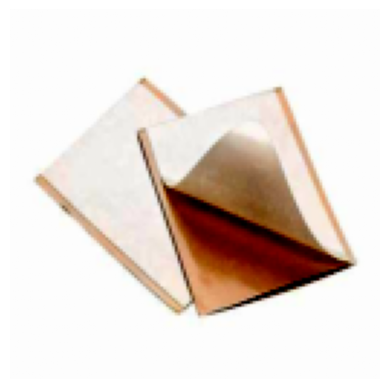

In [40]:
print("Label of this image is:", index_to_label[test_label])

img_rgb = test_image[0].permute(1, 2, 0).cpu()

plt.figure()
plt.imshow(img_rgb)
plt.axis("off")
comet_model.log_figure(figure=plt)
plt.show()

#2) Pretrained CNN Model (ResNet-18 fine-tune)

In [41]:
comet_ml.init(project_name="WasteClassificationCNN_pretrained")
comet_model_2 = comet_ml.Experiment()

COMET WARNING: comet_ml.init() is deprecated and will be removed soon. Please use comet_ml.login()
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : relaxed_tick_944
COMET INFO:     url                   : https://www.comet.com/parkorn-tuntiwattanakhul/deep-learning-project-1/e6b9293d1bbe4614a066834cf0805f90
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [1519] : (0.00328040006570518, 3.192821502685547)
COMET INFO:   Others:
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1kpHyFESEICajm5K_X6u1aNYFQHuWd6be
COMET INFO:   Uploads:
COMET INFO:     env

#Load Data Set

In [42]:
trainset_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True, persistent_workers=False
)
testset_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True, persistent_workers=False
)

# -----------------------------------------
#2) Define Pretrained Model (ResNet18)
# -----------------------------------------

In [43]:
backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = backbone.fc.in_features
backbone.fc = nn.Linear(in_features, len(index_to_label))
pretrained_model = backbone.to(device)

print(pretrained_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

/usr/local/lib/python3.12/dist-packages/torchviz/dot.py:65: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(torch.__version__) < LooseVersion("1.9") and \
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


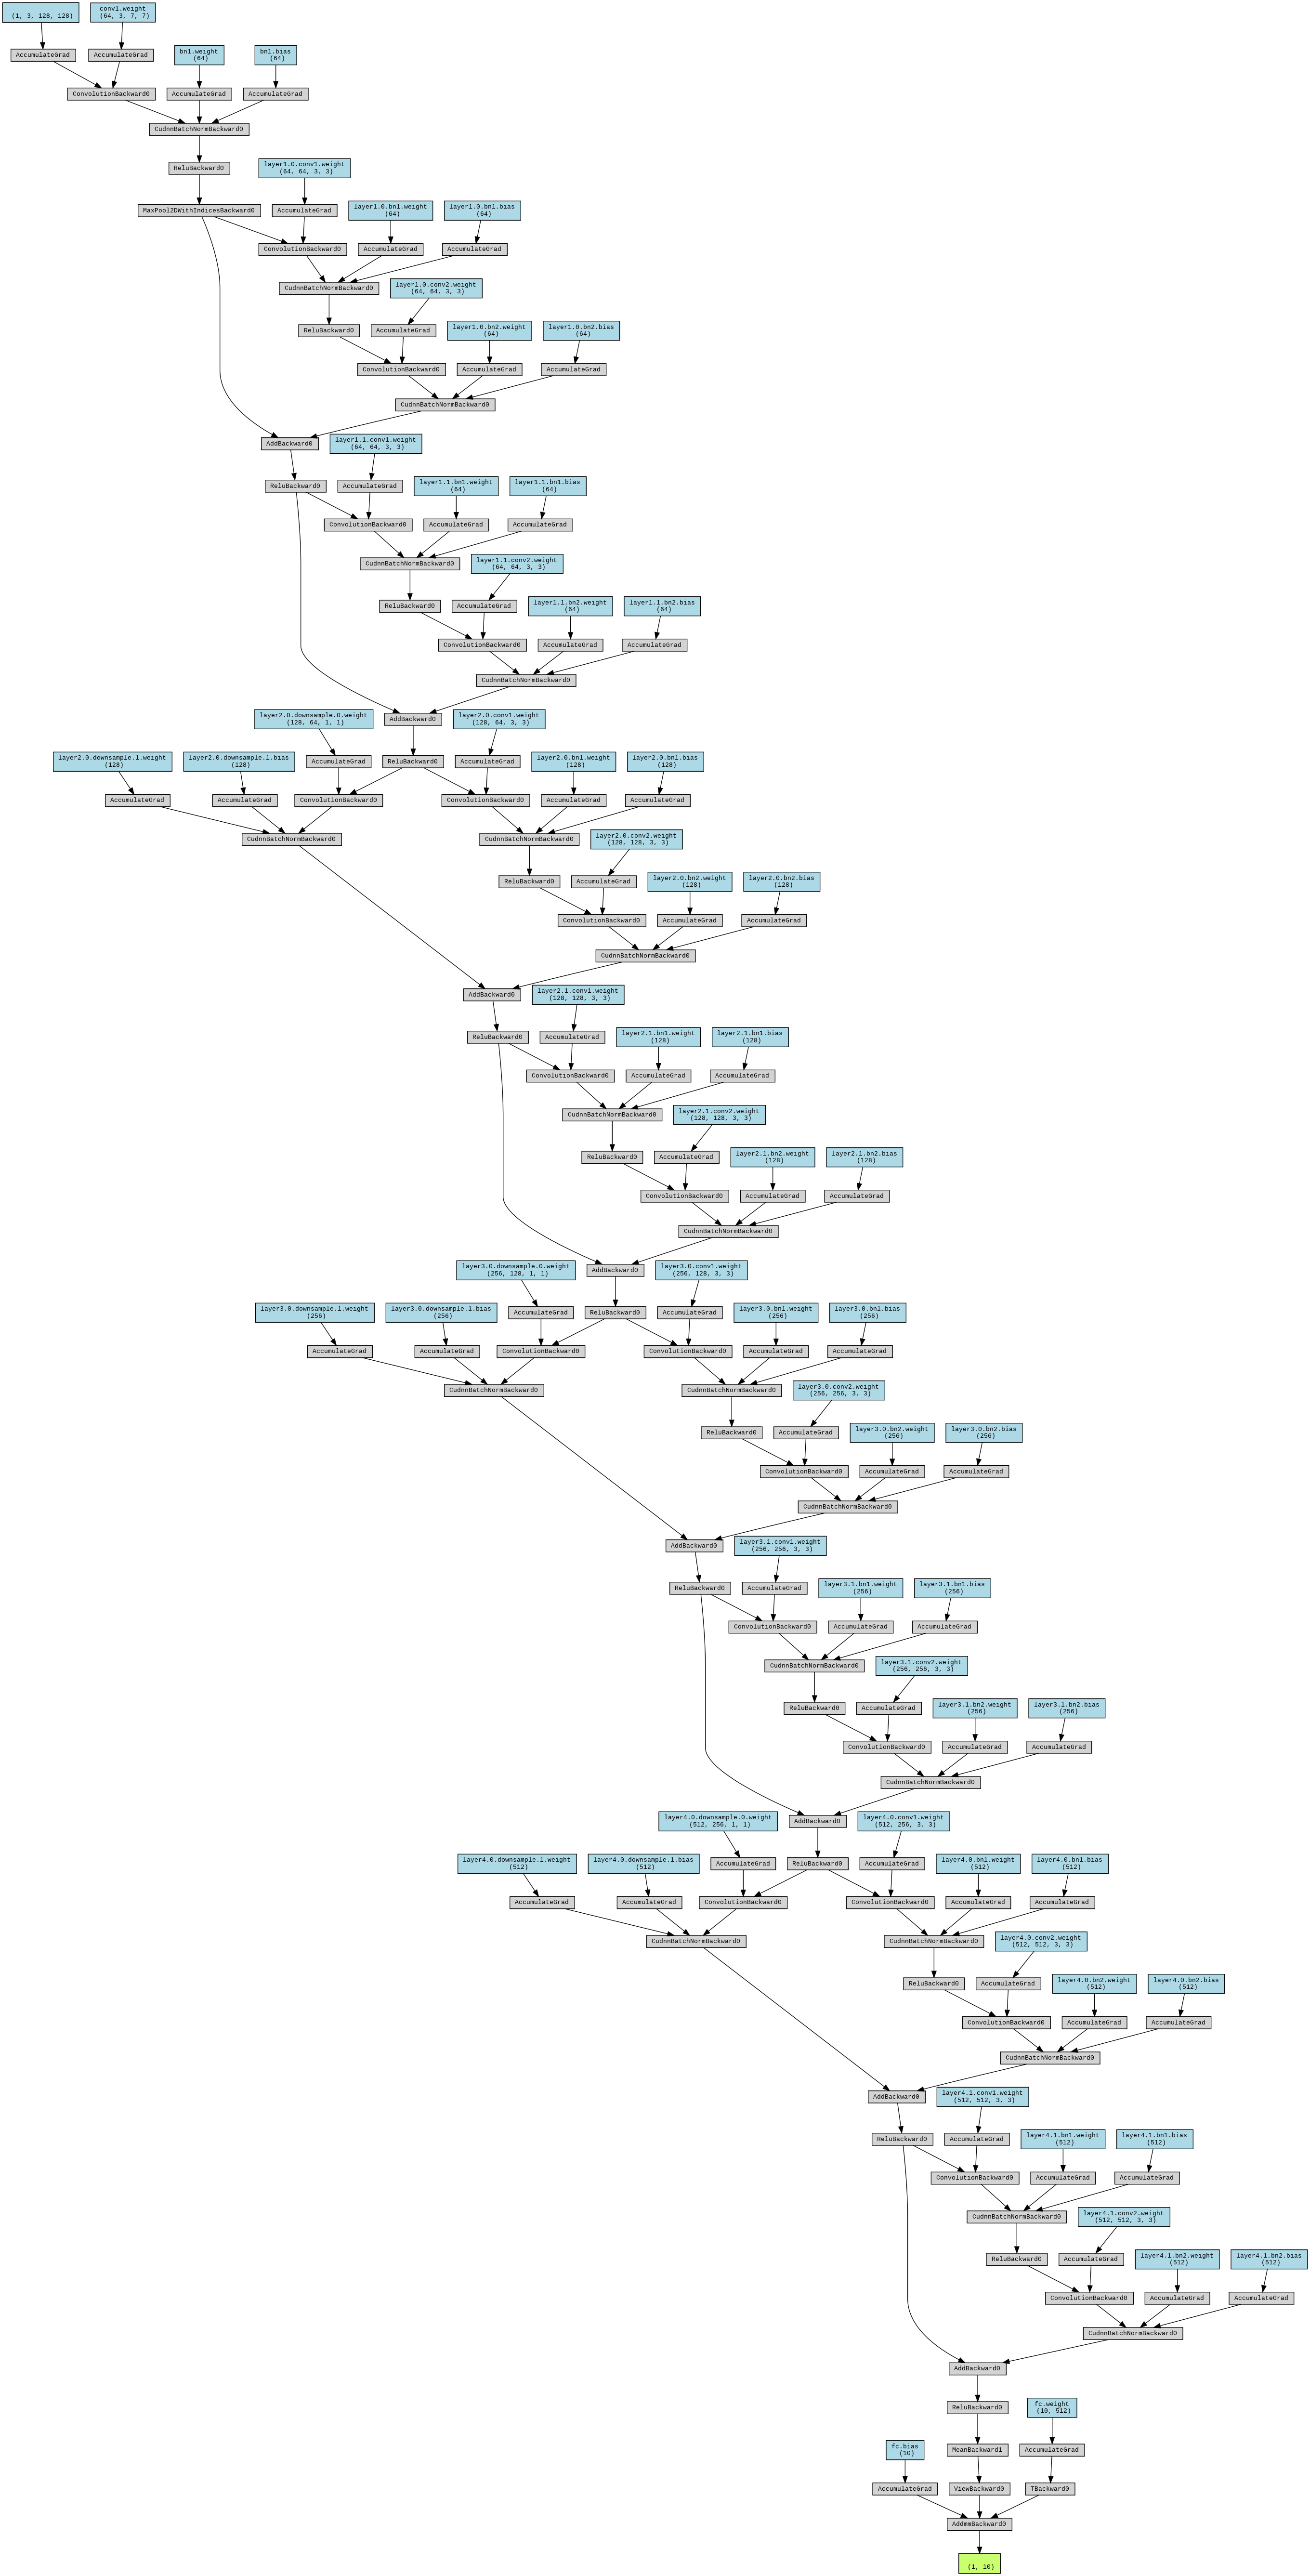

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


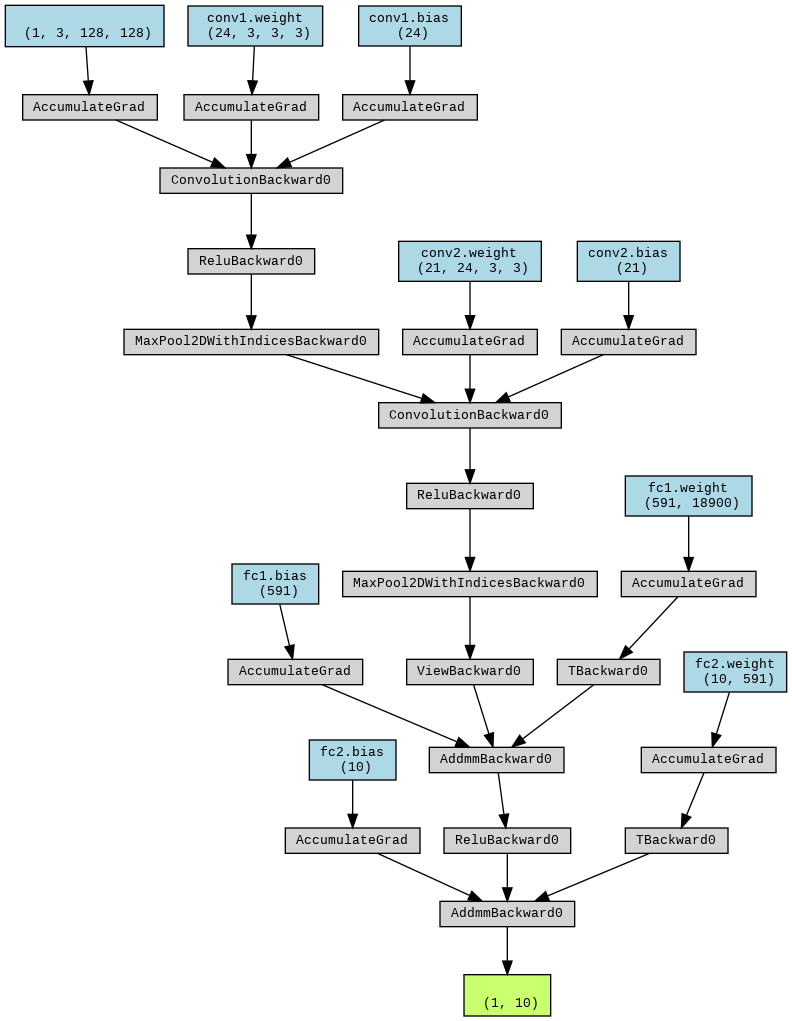

In [45]:
from IPython.display import display

# Find the device each model lives on
pre_dev = next(pretrained_model.parameters()).device
cnn_dev  = next(cnn_model.parameters()).device

# Dummy inputs ON THE SAME DEVICE as each model
x_pre = torch.randn(1, 3, 128, 128, device=pre_dev, requires_grad=True)
x_cnn = torch.randn(1, 3, 128, 128, device=cnn_dev,  requires_grad=True)

# Forward once (keep grad so torchviz can draw the graph)
y_pretrained = pretrained_model(x_pre)
y_cnn = cnn_model(x_cnn)

# Graphs
dot_pretrained = make_dot(y_pretrained, params=dict(pretrained_model.named_parameters()))
dot_cnn = make_dot(y_cnn, params=dict(cnn_model.named_parameters()))

dot_pretrained.render("Pretrained_CNN_Model_Structure", format="png")
dot_cnn.render("CNN_Model_Structure", format="png")

display(Image(filename="Pretrained_CNN_Model_Structure.png"))
display(Image(filename="CNN_Model_Structure.png"))
#summary(pretrained_model, input_size=(1, 3, 128, 128), device=str(pre_dev))
#summary(cnn_model,        input_size=(1, 3, 128, 128), device=str(cnn_dev))


# Define Training Parameters

In [46]:
# --- Config (kept same as scratch for apples-to-apples) ---
num_classes   = len(index_to_label)
batch_size    = 64
epochs        = 7
lr            = 0.001
weight_decay  = 5e-4
label_smoothing = 0.0

feature_extractor_mode = False   # freeze backbone; train only the head

criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = optim.AdamW([p for p in pretrained_model.parameters() if p.requires_grad],
                       lr=lr, weight_decay=weight_decay)

#Compare both models' parameters for fairness

In [47]:
cnn_total, cnn_trainable = count_parameters(cnn_model)
res_total, res_trainable = count_parameters(pretrained_model)   # your pretrained ResNet-18 variable

print("===== PARAMETER COMPARISON =====")
print(f"Custom CNN:")
print(f"  Total parameters     : {cnn_total:,}")
print(f"  Trainable parameters : {cnn_trainable:,}")
print()
print(f"Pretrained ResNet-18:")
print(f"  Total parameters     : {res_total:,}")
print(f"  Trainable parameters : {res_trainable:,}")


===== PARAMETER COMPARISON =====
Custom CNN:
  Total parameters     : 11,181,640
  Trainable parameters : 11,181,640

Pretrained ResNet-18:
  Total parameters     : 11,181,642
  Trainable parameters : 11,181,642


#Training Loop

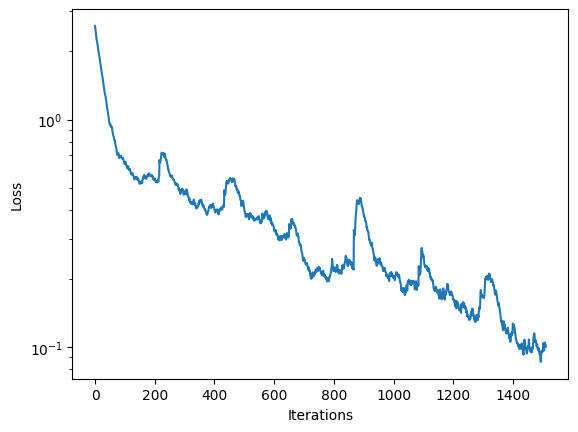

Epoch 7: train_loss=0.1207 acc=0.9616 | val_loss=0.5297 acc=0.8631


{'web': 'https://www.comet.com/api/image/download?imageId=29fd78bdcdaf4677aa9e49dec3974711&experimentKey=bc5fb3824a134d888ad37e665ae4cc30',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=29fd78bdcdaf4677aa9e49dec3974711&experimentKey=bc5fb3824a134d888ad37e665ae4cc30',
 'imageId': '29fd78bdcdaf4677aa9e49dec3974711'}

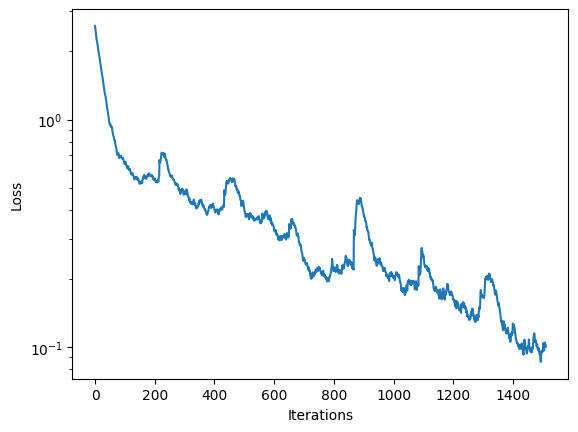

In [48]:
loss_history = mdl.util.LossHistory(smoothing_factor=0.95)
plotter = mdl.util.PeriodicPlotter(sec=2, xlabel='Iterations', ylabel='Loss', scale='semilogy')

# --- Train loop ---
if hasattr(tqdm, '_instances'): tqdm._instances.clear()
best_val_acc = 0.0
best_path = "resnet18_pretrained_best.pt"
global_step = 0

for epoch in range(epochs):
    pretrained_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for idx, (images, labels) in enumerate(tqdm(trainset_loader)):
        images, labels = images.to(device), labels.to(device)

        logits = pretrained_model(images)
        loss = criterion(logits, labels)

        # Log per-step loss to Comet and plotter (like your CNN)
        loss_value = loss.item()
        comet_model_2.log_metric("loss", loss_value, step=global_step)
        loss_history.append(loss_value)
        plotter.plot(loss_history.get())

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss_value * images.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        global_step += 1

    train_loss = running_loss / total
    train_acc  = correct / total

    # Validation
    val_loss, val_acc = evaluate(pretrained_model, testset_loader, criterion)

    # Epoch-level logs
    comet_model_2.log_metrics(
        {"train_loss": train_loss, "train_acc": train_acc,
         "val_loss": val_loss, "val_acc": val_acc},
        step=epoch
    )

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f}")

    # Save & log best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"state_dict": pretrained_model.state_dict(), "num_classes": num_classes}, best_path)
        comet_model_2.log_model("resnet18_pretrained_best", best_path)


comet_model_2.log_figure(figure=plt)


#Save the Model

In [49]:
torch.save(pretrained_model.state_dict(), "cnn_pretrained_model_resnet18.pt")

#Evaluate the model

In [50]:
val_loss, val_acc = evaluate(pretrained_model, testset_loader, loss_function)
print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

Validation Loss: 0.5297, Accuracy: 0.8631


In [51]:
random_inds = np.random.choice(len(train_dataset), 36, replace=False)
test_image, test_label = test_dataset[0]
test_image = test_image.to(device).unsqueeze(0)

# put the model in evaluation (inference) mode
pretrained_model.eval()
predictions_test_image = cnn_model(test_image)

In [52]:
random_inds = np.random.choice(len(test_dataset), 50, replace=False)  # 5 random samples

for idx in random_inds:
    test_image, test_label = test_dataset[idx]
    test_image = test_image.to(device).unsqueeze(0)

    cnn_model.eval()
    with torch.no_grad():
        predictions = pretrained_model(test_image)
        predicted_label = torch.argmax(predictions, dim=1).item()

    print(f"True: {test_dataset.classes[test_label]:<12}, Predicted: {test_dataset.classes[predicted_label]:<12}", end=" ")
    if (test_label != predicted_label):
        print("wrong")
    else:
        print("correct")

True: clothes     , Predicted: clothes      correct
True: clothes     , Predicted: clothes      correct
True: clothes     , Predicted: clothes      correct
True: clothes     , Predicted: clothes      correct
True: glass       , Predicted: plastic      wrong
True: trash       , Predicted: biological   wrong
True: glass       , Predicted: glass        correct
True: trash       , Predicted: trash        correct
True: plastic     , Predicted: glass        wrong
True: clothes     , Predicted: clothes      correct
True: clothes     , Predicted: clothes      correct
True: glass       , Predicted: glass        correct
True: trash       , Predicted: trash        correct
True: paper       , Predicted: paper        correct
True: glass       , Predicted: glass        correct
True: metal       , Predicted: metal        correct
True: plastic     , Predicted: plastic      correct
True: shoes       , Predicted: shoes        correct
True: shoes       , Predicted: shoes        correct
True: paper       

Random test sample index: 596
True label: clothes
Predicted: clothes  (p=1.0000)
Top-5:
  1. clothes: 1.0000
  2. paper: 0.0000
  3. shoes: 0.0000
  4. plastic: 0.0000
  5. trash: 0.0000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


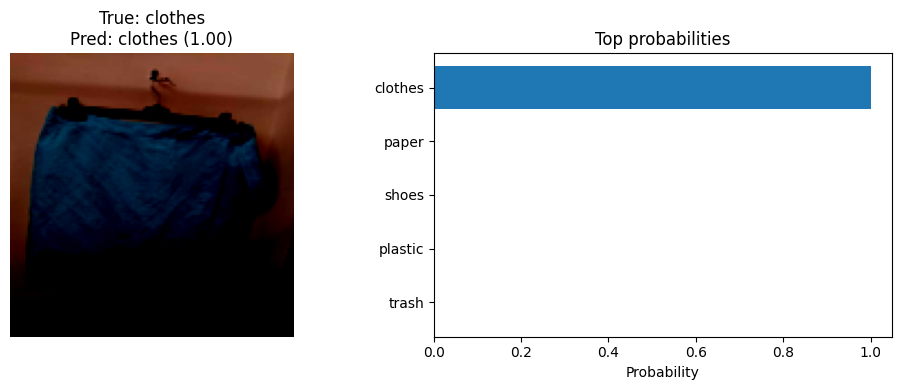

In [53]:
DEVICE = device  # use your existing 'device'
MODEL  = pretrained_model
DATASET = test_dataset            # torch.utils.data.Dataset
IDX2LBL = index_to_label          # e.g., {0:"cat",1:"dog",...}

# Set to True if you used transforms.Normalize on the dataset
DENORMALIZE = False
# Fill these if DENORMALIZE=True (use your actual dataset mean/std)
MEAN = [0.485, 0.456, 0.406]  # example (ImageNet-style)
STD  = [0.229, 0.224, 0.225]

def denorm(img_tensor, mean, std):
    """
    img_tensor: (C,H,W) in torch.FloatTensor
    returns: (C,H,W) de-normalized, clipped to [0,1]
    """
    m = torch.tensor(mean, device=img_tensor.device).view(-1, 1, 1)
    s = torch.tensor(std,  device=img_tensor.device).view(-1, 1, 1)
    out = img_tensor * s + m
    return out.clamp(0, 1)

# ---- sample 1 image from test set ----
MODEL.eval()
idx = random.randrange(len(DATASET))
img, true_label = DATASET[idx]   # img: (3,H,W), true_label: int

# (optional) de-normalize for display only
disp_img = denorm(img, MEAN, STD) if DENORMALIZE else img

# move to device, add batch dim
img_batch = img.unsqueeze(0).to(DEVICE)

# ---- forward pass ----
with torch.no_grad():
    logits = MODEL(img_batch)           # (1, num_classes)
    probs  = F.softmax(logits, dim=1)   # (1, num_classes)

probs_np = probs.squeeze(0).cpu().numpy()     # (num_classes,)
pred_idx = int(probs.argmax(dim=1).item())
pred_lbl = IDX2LBL[pred_idx]
true_lbl_name = IDX2LBL[int(true_label)]

# ---- sort classes by probability (descending) ----
classes = [IDX2LBL[i] for i in range(len(probs_np))]
order = np.argsort(-probs_np)
sorted_probs = probs_np[order]
sorted_classes = [classes[i] for i in order]

# ---- print top-5 ----
topk = 5 if len(sorted_probs) >= 5 else len(sorted_probs)
print(f"Random test sample index: {idx}")
print(f"True label: {true_lbl_name}")
print(f"Predicted: {pred_lbl}  (p={probs_np[pred_idx]:.4f})")
print("Top-5:")
for k in range(topk):
    print(f"  {k+1}. {sorted_classes[k]}: {sorted_probs[k]:.4f}")

# ---- plot image + probability bar chart ----
plt.figure(figsize=(10,4))

# left: image
plt.subplot(1,2,1)
plt.imshow(disp_img.permute(1,2,0).cpu())  # CHW -> HWC
plt.title(f"True: {true_lbl_name}\nPred: {pred_lbl} ({probs_np[pred_idx]:.2f})")
plt.axis("off")

# right: bar chart (top-k for readability)
plt.subplot(1,2,2)
y_pos = np.arange(topk)
plt.barh(y_pos, sorted_probs[:topk])
plt.yticks(y_pos, sorted_classes[:topk])
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Probability")
plt.title("Top probabilities")

# Log to Comet BEFORE showing/closing
try:
    comet_model.log_figure(figure=plt)
except Exception as e:
    print("Comet log_figure warning:", e)

plt.tight_layout()
plt.show()

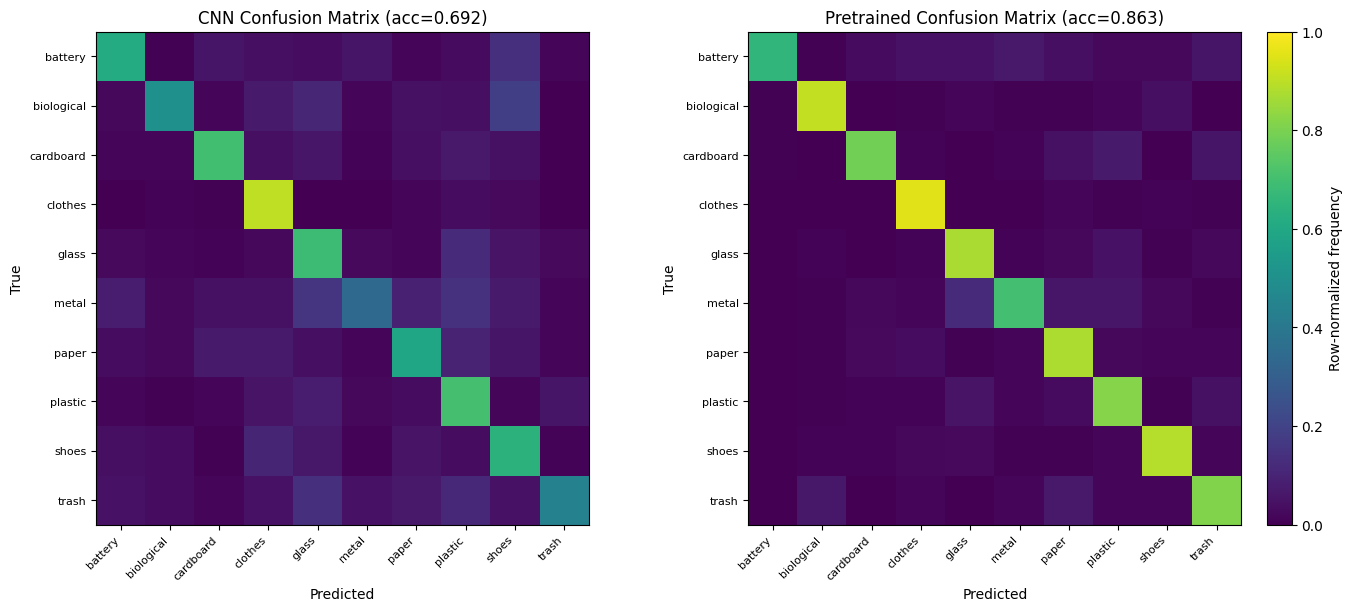

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


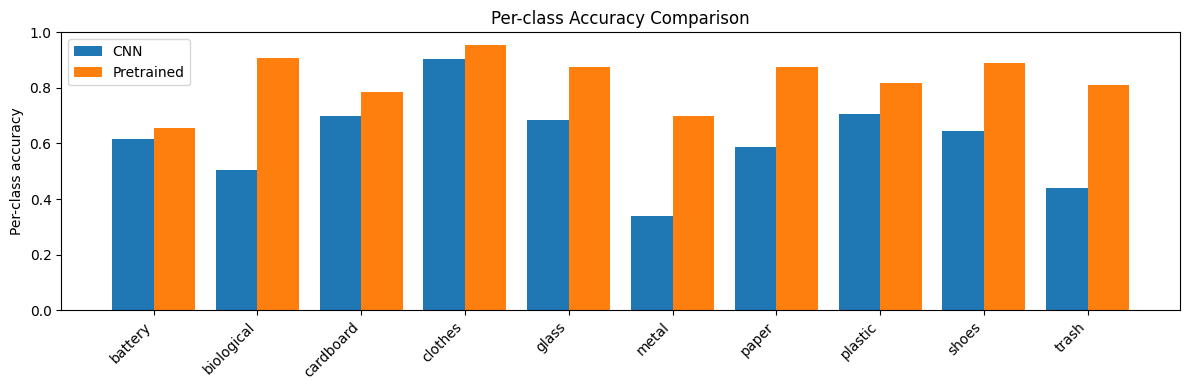

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [54]:
# Confusion matrices for CNN vs. Pretrained on the same test set
# Prereqs:
# - cnn_model, pretrained_model already defined & loaded
# - testset_loader (DataLoader) defined
# - device defined (cpu/cuda)
# - test_dataset or index_to_label available for class names

import torch
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# --- helper to run a model and collect preds/labels ---
@torch.no_grad()
def collect_preds(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        y_true.append(labels.cpu().numpy())
        y_pred.append(preds.cpu().numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return y_true, y_pred

# --- class names ---
if hasattr(test_dataset, "classes"):
    class_names = list(test_dataset.classes)
elif 'index_to_label' in globals():
    class_names = [index_to_label[i] for i in range(len(index_to_label))]
else:
    # fallback to indices
    class_names = [str(i) for i in range(cnn_model.fc2.out_features)] if hasattr(cnn_model, "fc2") else None

# --- collect predictions ---
y_true_cnn, y_pred_cnn = collect_preds(cnn_model,        testset_loader, device)
y_true_pre, y_pred_pre = collect_preds(pretrained_model, testset_loader, device)

# Sanity: they should be the same ground-truth order
assert (y_true_cnn == y_true_pre).all(), "Ground-truth mismatch across runs. Did you shuffle differently?"

# --- confusion matrices ---
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn, labels=range(len(class_names)))
cm_pre = confusion_matrix(y_true_pre, y_pred_pre, labels=range(len(class_names)))

acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
acc_pre = accuracy_score(y_true_pre, y_pred_pre)

# Normalize per-row (true class) for comparability (set normalize=False to view raw counts)
def normalize_rows(cm):
    with np.errstate(all='ignore'):
        row_sums = cm.sum(axis=1, keepdims=True)
        norm = np.divide(cm, row_sums, where=row_sums!=0)
    return norm

cm_cnn_norm = normalize_rows(cm_cnn)
cm_pre_norm = normalize_rows(cm_pre)

# Use the SAME color scale range for both plots to compare fairly
vmin = 0.0
vmax = 1.0  # because row-normalized

# --- plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im1 = axes[0].imshow(cm_cnn_norm, vmin=vmin, vmax=vmax)
axes[0].set_title(f"CNN Confusion Matrix (acc={acc_cnn:.3f})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticks(range(len(class_names)))
axes[0].set_yticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(class_names, fontsize=8)

im2 = axes[1].imshow(cm_pre_norm, vmin=vmin, vmax=vmax)
axes[1].set_title(f"Pretrained Confusion Matrix (acc={acc_pre:.3f})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_xticks(range(len(class_names)))
axes[1].set_yticks(range(len(class_names)))
axes[1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(class_names, fontsize=8)

# Single shared colorbar
cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), fraction=0.046, pad=0.02)
cbar.set_label("Row-normalized frequency")

plt.show()

# --- Optional: log figure to Comet (avoid empty-figure warning by logging before close) ---
# comet_model_2.log_figure(figure=plt)  # uncomment if comet_model_2 is active

# --- Also handy: per-class accuracies comparison ---
per_class_acc_cnn = np.diag(cm_cnn) / np.maximum(1, cm_cnn.sum(axis=1))
per_class_acc_pre = np.diag(cm_pre) / np.maximum(1, cm_pre.sum(axis=1))

plt.figure(figsize=(12,4))
x = np.arange(len(class_names))
width = 0.4
plt.bar(x - width/2, per_class_acc_cnn, width=width, label="CNN")
plt.bar(x + width/2, per_class_acc_pre, width=width, label="Pretrained")
plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.ylabel("Per-class accuracy")
plt.title("Per-class Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.show()
# comet_model_2.log_figure(figure=plt)  # optional